In [1]:
import sys
import random
import string

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.bloom_filter import BloomFilter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

random.seed(42)

In [2]:
def generate_random_strings(n, length=20):
    """Generate n random alphanumeric strings."""
    chars = string.ascii_letters + string.digits
    return [''.join(random.choices(chars, k=length)) for _ in range(n)]

## Memory usage

In [3]:
results = {
    'n_elements': [],
    'bloom_kb': [],
    'set_kb': [],
    'direct_kb': [],
    'compression_ratio': []
}

element_counts = [1000, 5000, 10000, 25000, 50000, 100000]
for n in element_counts:
    elements = generate_random_strings(n)
    
	# filter
    bf = BloomFilter(capacity=n, error_rate=0.01)
    for elem in elements:
        bf.add(elem)
    bloom_size = bf.memory_size_bytes / 1024
    
    # set
    py_set = set(elements)
    set_size = sys.getsizeof(py_set)
    string_size = sum(sys.getsizeof(s) for s in elements)
    set_total = (set_size + string_size) / 1024
    
    # direct storage
    direct_list = list(elements)
    direct_size = (sys.getsizeof(direct_list) + string_size) / 1024
    
    ratio = bloom_size / direct_size * 100
    
    results['n_elements'].append(n)
    results['bloom_kb'].append(bloom_size)
    results['set_kb'].append(set_total)
    results['direct_kb'].append(direct_size)
    results['compression_ratio'].append(ratio)

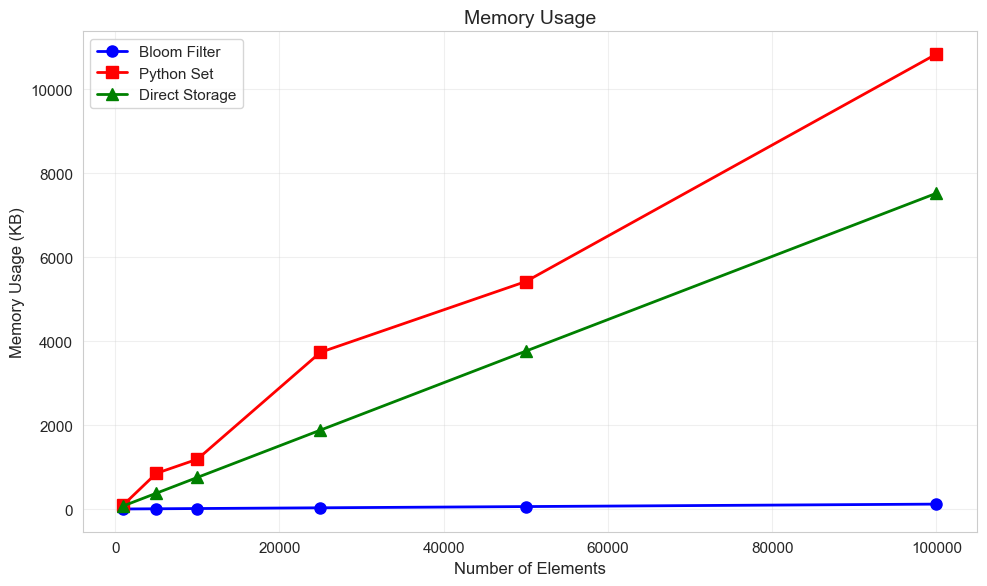

In [7]:
fig, ax = plt.subplots()

x = np.array(results['n_elements'])

ax.plot(x, results['bloom_kb'], 'b-o', label='Bloom Filter', linewidth=2, markersize=8)
ax.plot(x, results['set_kb'], 'r-s', label='Python Set', linewidth=2, markersize=8)
ax.plot(x, results['direct_kb'], 'g-^', label='Direct Storage', linewidth=2, markersize=8)

ax.set_xlabel('Number of Elements', fontsize=12)
ax.set_ylabel('Memory Usage (KB)', fontsize=12)
ax.set_title('Memory Usage', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/compression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Memory vs accuracy

In [8]:


capacity_results = {'target_fp': [], 'memory_kb': [], 'measured_fp': [], 'bit_array': [], 'hash_fn': []}

num_elements = 10000
error_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
elements = generate_random_strings(num_elements)
for error_rate in error_rates:
    bf = BloomFilter(capacity=num_elements, error_rate=error_rate)
    for elem in elements:
        bf.add(elem)
    
    test_elements = generate_random_strings(10000)
    false_positives = sum(1 for elem in test_elements if elem in bf)
    measured_fp = false_positives / len(test_elements)
    
    capacity_results['target_fp'].append(error_rate)
    capacity_results['memory_kb'].append(bf.memory_size_bytes / 1024)
    capacity_results['measured_fp'].append(measured_fp)
    capacity_results['bit_array'].append(bf.bit_array_size)
    capacity_results['hash_fn'].append(bf.num_hash_functions)

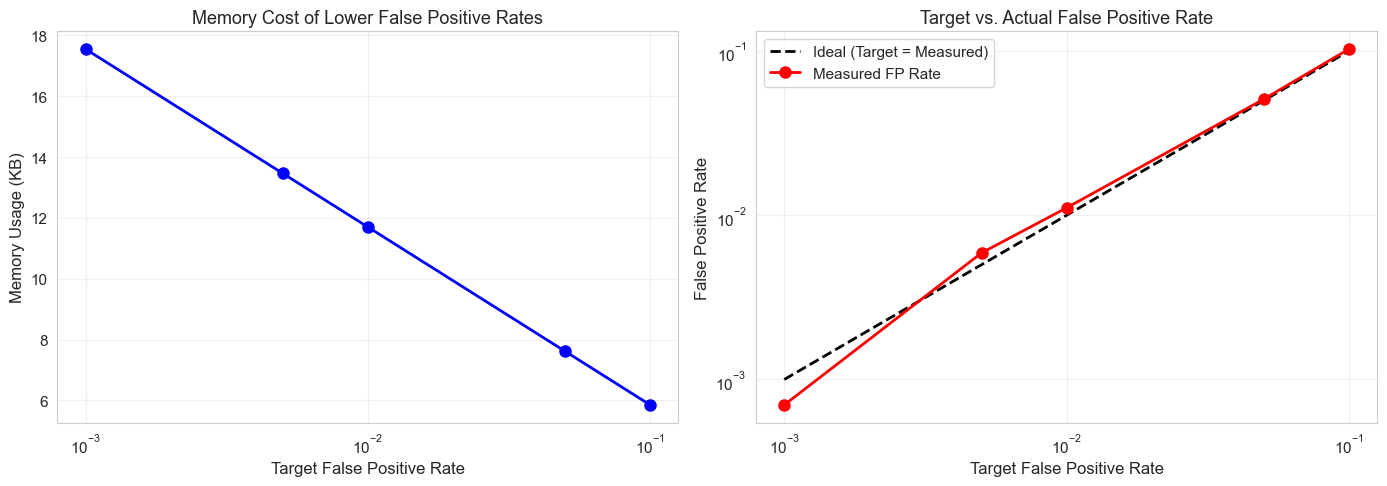

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Memory vs. target FP rate
ax1.plot(capacity_results['target_fp'], capacity_results['memory_kb'], 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Target False Positive Rate', fontsize=12)
ax1.set_ylabel('Memory Usage (KB)', fontsize=12)
ax1.set_title('Memory Cost of Lower False Positive Rates', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# target vs. measured FP rate
ax2.plot(capacity_results['target_fp'], capacity_results['target_fp'], 'k--', 
         label='Ideal (Target = Measured)', linewidth=2)
ax2.plot(capacity_results['target_fp'], capacity_results['measured_fp'], 'r-o', 
         label='Measured FP Rate', linewidth=2, markersize=8)
ax2.set_xlabel('Target False Positive Rate', fontsize=12)
ax2.set_ylabel('False Positive Rate', fontsize=12)
ax2.set_title('Target vs. Actual False Positive Rate', fontsize=13)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('./plots/fp_rate_vs_capacity.png', dpi=150, bbox_inches='tight')
plt.show()